<a href="https://colab.research.google.com/github/uguazelli/scikit_learn/blob/main/decision_tree101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gini Impurity Explained

## ✅ What is Gini Impurity?

Gini impurity measures how "impure" or mixed a node is.

* A pure node (all samples belong to the same class) has Gini = 0.
* A 50/50 mix has maximum impurity.

## 🧮 Gini Impurity Formula

The formula for Gini Impurity is:

$$ \text{Gini}(D) = 1 - \sum_{i=1}^{C} p_i^2 $$

Where:
* $D$: the dataset (or node)
* $C$: number of classes
* $p_i$: proportion of class $i$ in the node

## 🔢 Example: Binary Classification (Setosa vs Virginica)

Imagine a node has 10 samples:

* 4 are Setosa
* 6 are Virginica

So:

* $p_{\text{Setosa}} = 4/10 = 0.4$
* $p_{\text{Virginica}} = 6/10 = 0.6$

Now plug into the formula:

$$ \text{Gini} = 1 - (0.4^2 + 0.6^2) = 1 - (0.16 + 0.36) = 1 - 0.52 = \boxed{0.48} $$

Let's calculate this using Python:
def calculate_gini_impurity(proportions):
"""
Calculates Gini impurity for a given set of class proportions.

Args:
proportions: A list or tuple of class proportions (e.g., [0.4, 0.6]).

Returns:
The Gini impurity value.
"""
sum_of_squares = sum(p**2 for p in proportions)
gini = 1 - sum_of_squares
return gini

Example usage:
setosa_proportion = 4/10
virginica_proportion = 6/10
proportions = [setosa_proportion, virginica_proportion]

gini_value = calculate_gini_impurity(proportions)
print(f"Gini Impurity for the example: {gini_value:.2f}")


## 🎯 Interpretation:

| Gini Value | Meaning                       |
| :--------- | :---------------------------- |
| 0.00       | Pure (all same class)         |
| 0.48       | Mixed (more impurity)         |
| 0.50       | Max impurity for 2-class case |
| ~0.67      | Max impurity for 3 equal classes |

So, lower Gini = better split (more pure children).

## 🧠 How the Tree Uses Gini

At each node:

1.  Try every feature and split value.
2.  For each split:
    * Compute Gini for the left and right child nodes.
    * Compute the weighted average impurity using the formula:

    $$ Gini_{\text{split}} = \frac{n_{\text{left}}}{n} Gini_{\text{left}} + \frac{n_{\text{right}}}{n} Gini_{\text{right}} $$

    Where $n_{\text{left}}$ and $n_{\text{right}}$ are the number of samples in the left and right child nodes, respectively, and $n$ is the total number of samples in the parent node.

3.  Pick the split with the lowest $Gini_{\text{split}}$.

```python
# Example of calculating weighted average Gini Impurity for a split
def calculate_weighted_gini(n_parent, gini_parent, n_left, gini_left, n_right, gini_right):
  """
  Calculates the weighted average Gini impurity for a split.

  Args:
    n_parent: Total number of samples in the parent node.
    gini_parent: Gini impurity of the parent node (though not directly used in weighted average,
                 good to conceptualize).
    n_left: Number of samples in the left child node.
    gini_left: Gini impurity of the left child node.
    n_right: Number of samples in the right child node.
    gini_right: Gini impurity of the right child node.

  Returns:
    The weighted average Gini impurity of the split.
  """
  weighted_gini = (n_left / n_parent) * gini_left + \
                  (n_right / n_parent) * gini_right
  return weighted_gini

# Hypothetical split scenario
total_samples_parent = 100
gini_parent = 0.45 # For context, not directly used in weighted average formula

# Split 1
n_left_1 = 60
gini_left_1 = 0.20
n_right_1 = 40
gini_right_1 = 0.30
weighted_gini_1 = calculate_weighted_gini(total_samples_parent, gini_parent, n_left_1, gini_left_1, n_right_1, gini_right_1)
print(f"Weighted Gini for Split 1: {weighted_gini_1:.3f}")

# Split 2
n_left_2 = 30
gini_left_2 = 0.10
n_right_2 = 70
gini_right_2 = 0.50
weighted_gini_2 = calculate_weighted_gini(total_samples_parent, gini_parent, n_left_2, gini_left_2, n_right_2, gini_right_2)
print(f"Weighted Gini for Split 2: {weighted_gini_2:.3f}")

# The tree would choose Split 1 as it has a lower weighted Gini.
🗣️ How to explain it in a presentation:
"Gini impurity tells us how mixed a group is. If a node has only one class, the Gini is 0 — it's perfectly clean. But if it's a 50/50 split, the Gini is 0.5 — the dirtiest it can be. The Decision Tree keeps splitting in ways that reduce this impurity, so that each branch leads to more confident predictions."

✅ Summary:
Gini is a measure of how mixed the labels are in a node.

Used to decide the best feature and threshold to split on.

Lower Gini = better, purer node = better decision.

In [1]:
# 📌 Step 1: Install dependencies (only needed if not already installed)
!pip install graphviz
!apt-get install -qq libgraphviz-dev

Selecting previously unselected package libgtk2.0-common.
(Reading database ... 126308 files and directories currently installed.)
Preparing to unpack .../0-libgtk2.0-common_2.24.33-2ubuntu2.1_all.deb ...
Unpacking libgtk2.0-common (2.24.33-2ubuntu2.1) ...
Selecting previously unselected package libgtk2.0-0:amd64.
Preparing to unpack .../1-libgtk2.0-0_2.24.33-2ubuntu2.1_amd64.deb ...
Unpacking libgtk2.0-0:amd64 (2.24.33-2ubuntu2.1) ...
Selecting previously unselected package libgail18:amd64.
Preparing to unpack .../2-libgail18_2.24.33-2ubuntu2.1_amd64.deb ...
Unpacking libgail18:amd64 (2.24.33-2ubuntu2.1) ...
Selecting previously unselected package libgail-common:amd64.
Preparing to unpack .../3-libgail-common_2.24.33-2ubuntu2.1_amd64.deb ...
Unpacking libgail-common:amd64 (2.24.33-2ubuntu2.1) ...
Selecting previously unselected package libxdot4:amd64.
Preparing to unpack .../4-libxdot4_2.42.2-6ubuntu0.1_amd64.deb ...
Unpacking libxdot4:amd64 (2.42.2-6ubuntu0.1) ...
Selecting previousl

In [2]:
# 📌 Step 2: Import libraries
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn import tree
import graphviz

In [3]:
# 📌 Step 3: Load sample dataset
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
target_names = iris.target_names

In [4]:
# 📌 Step 4: Split data into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [5]:
# 📌 Step 5: Train the Decision Tree
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [6]:
# 📌 Step 6: Evaluate model
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



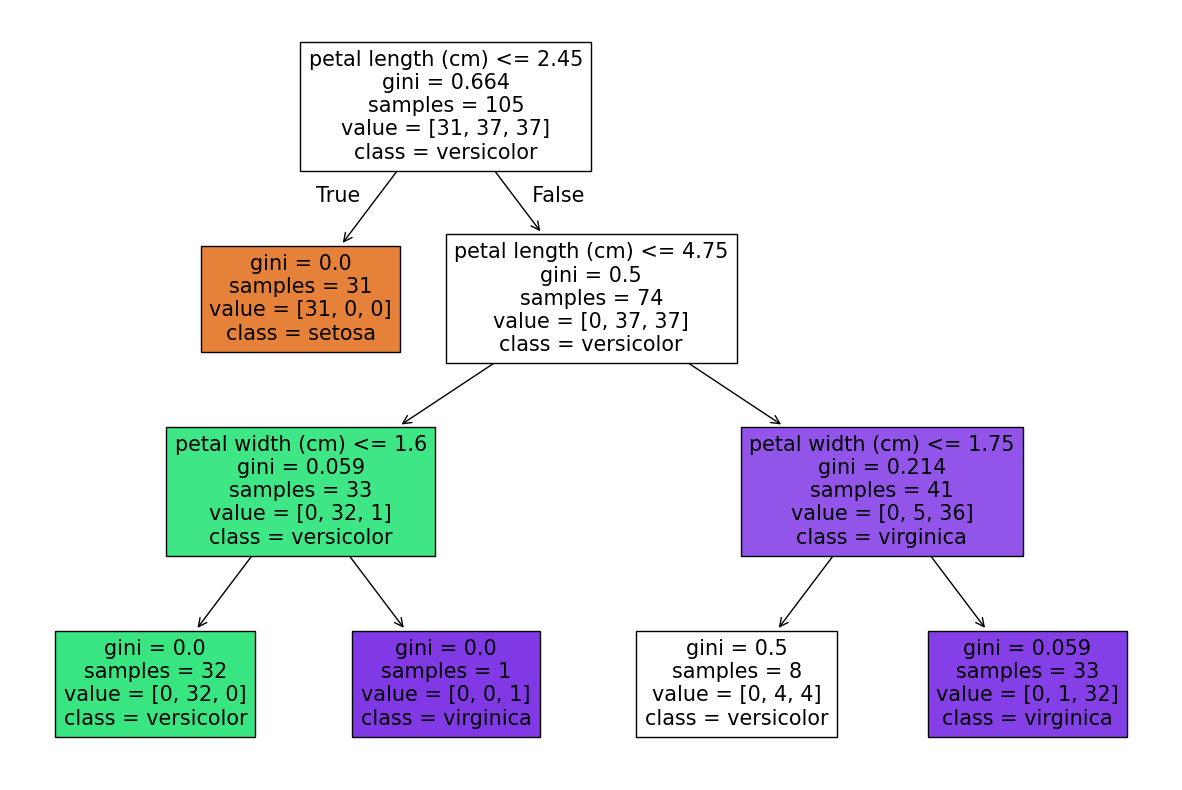

In [7]:
# 📌 Step 7: Visualize the tree (text version)
plt.figure(figsize=(15, 10))
tree.plot_tree(clf, feature_names=feature_names, class_names=target_names, filled=True)
plt.show()

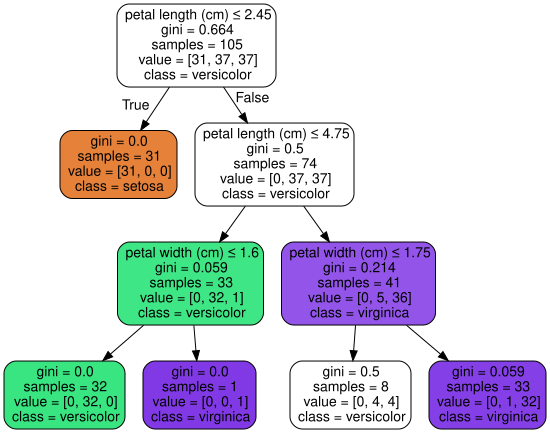

In [8]:
# 📌 Step 8: Visualize with Graphviz (better style)
dot_data = export_graphviz(clf, out_file=None,
                           feature_names=feature_names,
                           class_names=target_names,
                           filled=True, rounded=True,
                           special_characters=True)
graph = graphviz.Source(dot_data)
graph.render("decision_tree")  # Saves as decision_tree.pdf
graph

In [9]:
# Example input: [sepal length, sepal width, petal length, petal width]
new_sample = [[5.1, 3.5, 1.4, 0.2]]

# Make prediction
prediction = clf.predict(new_sample)
print("Predicted class:", prediction)
print("Class name:", iris.target_names[prediction[0]])

Predicted class: [0]
Class name: setosa
